In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/exp/script_replay_AGU/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
rp2=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')
me2=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')

In [3]:
rp1=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')
me1=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')

In [4]:
rp=xr.concat((rp2,rp1),dim='time')
me=xr.concat((me2,me1),dim='time')

In [5]:
rp=rp[['T','QV','OMEGA']].compute()
me=me[['T','QV','OMEGA']].compute()

In [6]:
# x1 = -176
# x2 = -176
# y1 = -4
# y2 = -4

x1 = 143
x2 = 143
y1 = -1
y2 = -1


# x1=-127
# x2=-127
# y1=7
# y2=7

rpcpT=rp.T.sel(lon=x1,lat=y1,lev=slice(1000,200))
mecpT=me.T.sel(lon=x1,lat=y1,lev=slice(1000,200))

rpcpQ=rp.QV.sel(lon=x1,lat=y1,lev=slice(1000,200))
mecpQ=me.QV.sel(lon=x1,lat=y1,lev=slice(1000,200))

rpcpO=rp.OMEGA.sel(lon=x1,lat=y1,lev=slice(1000,200))
mecpO=me.OMEGA.sel(lon=x1,lat=y1,lev=slice(1000,200))

rpcpTO=rpcpT*rpcpO
mecpTO=mecpT*mecpO

rpcpQO=rpcpT*rpcpQ
mecpQO=mecpT*mecpQ


# rpcpT=rpcpT[1:,:].data-rpcpT[:-1,:]
# mecpT=mecpT[1:,:].data-mecpT[:-1,:]

# rpcpO=rpcpO[1:,:].data-rpcpO[:-1,:]
# mecpO=mecpO[1:,:].data-mecpO[:-1,:]

# rpcpTO2=rpcpT*rpcpO
# mecpTO2=mecpT*mecpO

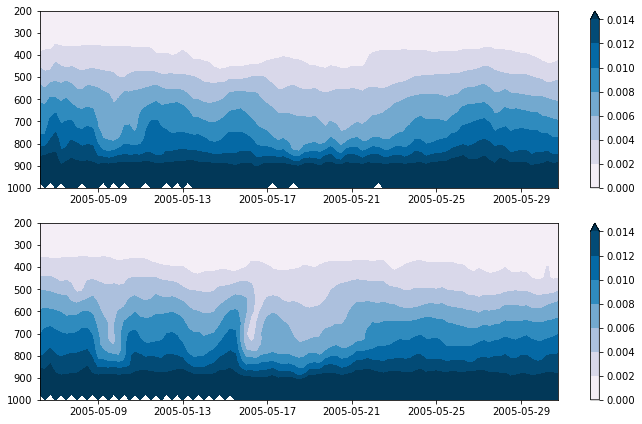

In [7]:
clf=arange(0,.015,.002)
cmap='PuBu'
f()
plt.subplot(2,1,1)
plt.contourf(mecpQ.sel(time=slice('2005-05-06','2005-05-30')).time,mecpQ.lev,mecpQ.sel(time=slice('2005-05-04','2005-05-30')).T,levels=clf,extend='max',cmap=cmap)
plt.gca().invert_yaxis()
plt.colorbar()

plt.subplot(2,1,2)
plt.contourf(mecpQ.sel(time=slice('2005-05-06','2005-05-30')).time,mecpQ.lev,rpcpQ.sel(time=slice('2005-05-04','2005-05-30')).T,levels=clf,extend='max',cmap=cmap)
plt.colorbar()
plt.gca().invert_yaxis()

In [8]:
import matplotlib.ticker as plticker

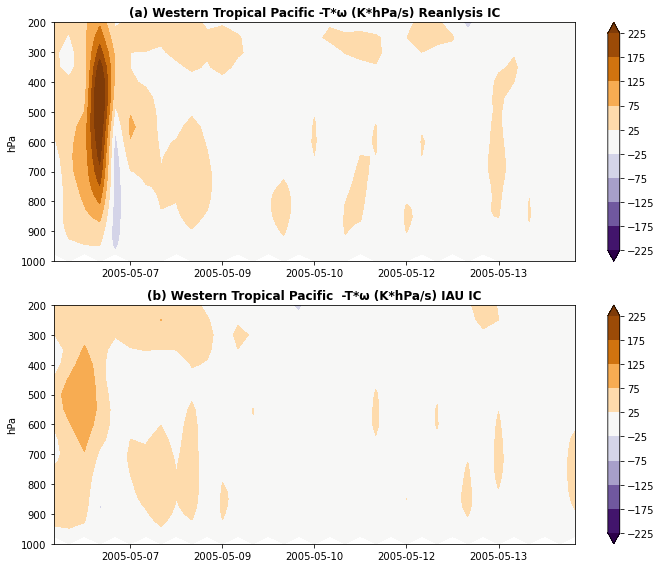

In [13]:
clf=arange(-225,226,50)
clf2=array([-.45, -.4, -.3, .3, .4, .45])
cmap='PuOr_r'
plt.figure(figsize=(10,8))
ax=plt.subplot(2,1,1)
#cs=plt.contour(mecpQ.sel(time=slice('2005-05-05','2005-05-15')).time,mecpQO.lev,mecpO.sel(time=slice('2005-05-05','2005-05-15')).T,levels=clf2,extend='max',colors='black')
#plt.clabel(cs)
plt.ylabel('hPa')
#plt.yscale('log')
plt.contourf(mecpT.sel(time=slice('2005-05-05','2005-05-14')).time,mecpT.lev,-mecpTO.sel(time=slice('2005-05-05','2005-05-14')).T,levels=clf,extend='both',cmap=cmap)
plt.colorbar()
plt.gca().invert_yaxis()
plt.title('(a) Western Tropical Pacific -T*ω (K*hPa/s) Reanlysis IC',fontsize=12,fontweight='bold')
loc = plticker.MultipleLocator(base=1.5) # this locator puts ticks at regular intervals
ax.xaxis.set_major_locator(loc)

ax=plt.subplot(2,1,2)
# cs=plt.contour(mecpQ.sel(time=slice('2005-05-05','2005-05-15')).time,mecpQ.lev,rpcpO.sel(time=slice('2005-05-05','2005-05-15')).T,levels=clf2,extend='max',colors='black')
# plt.clabel(cs)
plt.ylabel('hPa')
#plt.yscale('log')
plt.contourf(mecpT.sel(time=slice('2005-05-05','2005-05-14')).time,mecpT.lev,-rpcpTO.sel(time=slice('2005-05-05','2005-05-14')).T,levels=clf,extend='both',cmap=cmap)
plt.colorbar()
plt.title('(b) Western Tropical Pacific  -T*ω (K*hPa/s) IAU IC',fontsize=12,fontweight='bold')
loc = plticker.MultipleLocator(base=1.5) # this locator puts ticks at regular intervals
ax.xaxis.set_major_locator(loc)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('heat_WP.png',dpi=200)

##### 

In [30]:

rpT=rp.T.sel(lev=500)
meT=me.T.sel(lev=500)

# rpcpQ=rp.QV.sel(lon=x1,lat=y1,lev=slice(900,250))
# mecpQ=me.QV.sel(lon=x1,lat=y1,lev=slice(900,250))

rpO=rp.OMEGA.sel(lev=500)
meO=me.OMEGA.sel(lev=500)

rpTO=-rpT*rpO
meTO=-meT*meO


In [31]:

rpT=rp.T.sel(lev=400)
meT=me.T.sel(lev=400)

# rpcpQ=rp.QV.sel(lon=x1,lat=y1,lev=slice(900,250))
# mecpQ=me.QV.sel(lon=x1,lat=y1,lev=slice(900,250))

rpO=rp.OMEGA.sel(lev=400)
meO=me.OMEGA.sel(lev=400)

rpTO=-rpT*rpO
meTO=-meT*meO


In [32]:
# plt.figure(figsize=(10,8))
# # plt.subplot(2,1,1)
# # (rpcpTO.sel(time='2005-06-07',lat=slice(-10,10),lon=slice(-180,-100))[2,:,:]*-1).plot(levels=array([-300,-250,-200,200,250,300]),extend='both')

# plt.subplot(2,1,1)
# (mecpTO.sel(time='2005-05-12',lat=slice(-10,10),lon=slice(-180,-100))[2,:,:]*-1).plot(levels=array([-300,-250,-200,200,250,300]),extend='both')

# plt.subplot(2,1,2)
# (mecpTO.sel(time='2005-05-14',lat=slice(-10,10),lon=slice(-180,-100))[2,:,:]*-1).plot(levels=array([-300,-250,-200,200,250,300]),extend='both')

In [33]:
ticks=[]

for i in range(len(rpTO.time)):
    ticks=append(ticks,str(rpTO.time.data[i])[5:10])

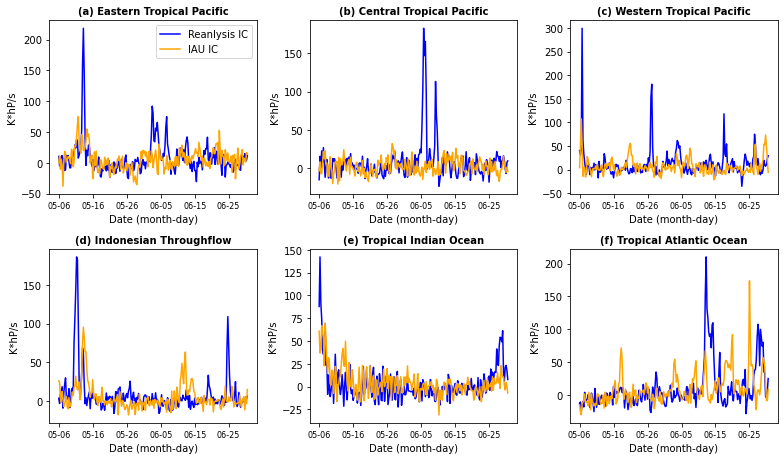

In [34]:
# ticks = []

# for i in range(len(meTO.time)):
#     ticks.append(str(meTO.time.data[i])[5:10])

x1 = -127
x2 = -127
y1 = 7
y2 = 7

plt.figure(figsize=(11, 6.5))

plt.subplot(2, 3, 1)
plt.plot((meTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((rpTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(a) Eastern Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::40], ticks[::40], fontsize=8)
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('K*hP/s')

x1 = -176
x2 = -176
y1 = -4
y2 = -4


plt.subplot(2, 3, 2)
plt.plot((meTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((rpTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(b) Central Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::40], ticks[::40], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('K*hP/s')

x1 = 143
x2 = 143
y1 = -1
y2 = -1

plt.subplot(2, 3, 3)
plt.plot((meTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((rpTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(c) Western Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::40], ticks[::40], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('K*hP/s')


x1 = 121
x2 = 122
y1 = 2
y2 = 6
plt.subplot(2, 3, 4)
plt.plot((meTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((rpTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(d) Indonesian Throughflow',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::40], ticks[::40], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('K*hP/s')


x1 = 89
x2 = 92
y1 = 7
y2 = 8

plt.subplot(2, 3, 5)
plt.plot((meTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((rpTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(e) Tropical Indian Ocean',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::40], ticks[::40], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('K*hP/s')

x1 = -39
x2 = -38
y1 = 7
y2 = 8

plt.subplot(2, 3, 6)
plt.plot((meTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((rpTO).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(f) Tropical Atlantic Ocean',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::40], ticks[::40], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('K*hP/s')

plt.tight_layout()
plt.savefig('spike_wt.png',dpi=150)